In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [2]:
dataset = pd.read_csv('Mall_Customers.csv')
print(dataset.head())
X = dataset.iloc[:, [3, 4]].values
print(X)


   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
[[ 15  39]
 [ 15  81]
 [ 16   6]
 [ 16  77]
 [ 17  40]
 [ 17  76]
 [ 18   6]
 [ 18  94]
 [ 19   3]
 [ 19  72]
 [ 19  14]
 [ 19  99]
 [ 20  15]
 [ 20  77]
 [ 20  13]
 [ 20  79]
 [ 21  35]
 [ 21  66]
 [ 23  29]
 [ 23  98]
 [ 24  35]
 [ 24  73]
 [ 25   5]
 [ 25  73]
 [ 28  14]
 [ 28  82]
 [ 28  32]
 [ 28  61]
 [ 29  31]
 [ 29  87]
 [ 30   4]
 [ 30  73]
 [ 33   4]
 [ 33  92]
 [ 33  14]
 [ 33  81]
 [ 34  17]
 [ 34  73]
 [ 37  26]
 [ 37  75]
 [ 38  35]
 [ 38  92]
 [ 39  36]
 [ 39  61]
 [ 39  28]
 [ 39  65]
 [ 40  55]
 [ 40  47]
 [ 40  42]
 [ 40  42]
 [ 42  52]
 [ 42  60]
 [

k=2, Silhouette Score=0.3835
k=3, Silhouette Score=0.4676
k=4, Silhouette Score=0.4936
k=5, Silhouette Score=0.5414
k=6, Silhouette Score=0.4532
k=7, Silhouette Score=0.4096
k=8, Silhouette Score=0.4038
k=9, Silhouette Score=0.3569


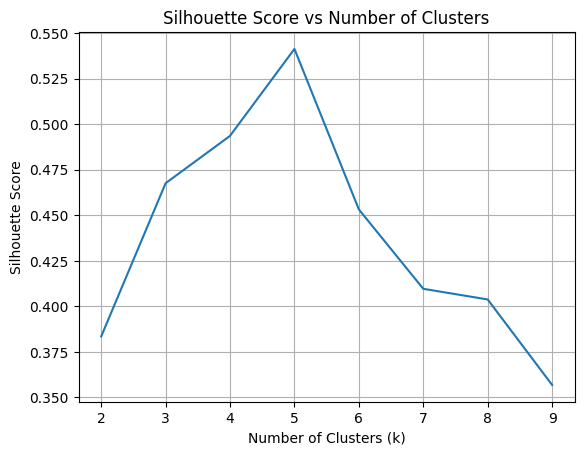

In [9]:
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score

sil_scores = []

for k in range(2, 10):
    sc = SpectralClustering(n_clusters=k, affinity='nearest_neighbors',  assign_labels='kmeans', n_neighbors=15,random_state=10)
    labels = sc.fit_predict(X)
    score = silhouette_score(X, labels)
    sil_scores.append(score)
    print(f'k={k}, Silhouette Score={score:.4f}')


# Plot
plt.plot(range(2, 10), sil_scores)
plt.title('Silhouette Score vs Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()


In [11]:
from sklearn.cluster import SpectralClustering
spclust = SpectralClustering(n_clusters=5, affinity='nearest_neighbors', n_neighbors=15, random_state=10)
y_spclust = spclust.fit_predict(X)


unique, counts = np.unique(y_spclust, return_counts=True)
print(dict(zip(unique, counts)))


{np.int32(0): np.int64(33), np.int32(1): np.int64(26), np.int32(2): np.int64(39), np.int32(3): np.int64(22), np.int32(4): np.int64(80)}


In [12]:
supervised=pd.DataFrame(dataset)

supervised['Cluster_group']=y_spclust

supervised


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster_group
0,1,Male,19,15,39,1
1,2,Male,21,15,81,3
2,3,Female,20,16,6,1
3,4,Female,23,16,77,3
4,5,Female,31,17,40,1
...,...,...,...,...,...,...
195,196,Female,35,120,79,2
196,197,Female,45,126,28,0
197,198,Male,32,126,74,2
198,199,Male,32,137,18,0


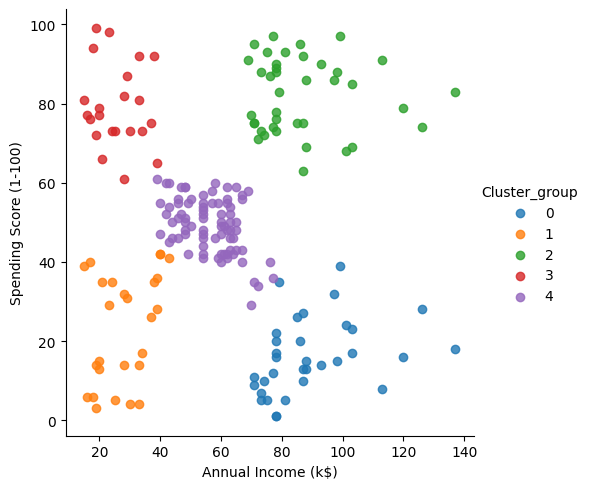

In [13]:
import seaborn as sns
facet = sns.lmplot(data=supervised, x=supervised.columns[3], y=supervised.columns[4], hue=supervised.columns[5], 
                   fit_reg=False, legend=True)
